In [58]:
# code here
import cv2
import matplotlib.pyplot as plt
import numpy as np

1)	A partir da imagem original obtenha as outras imagens conforme descrição

Desejamos separar linhas de círculos. Uma operação de abertura com um elemento estruturante na forma de círculo (definir o raio) faz essa tarefa. Gere uma imagem com os círculos e uma com as linhas


(np.float64(-0.5), np.float64(221.5), np.float64(216.5), np.float64(-0.5))

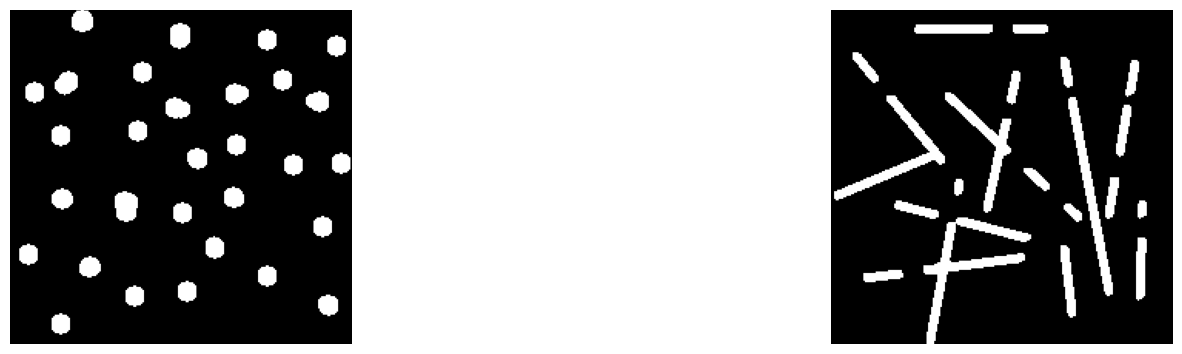

In [75]:
# Auxiliares (Ignorar)
# Elemento estruturante, matriz 4x4 de 1
""" kernel = np.ones((4,4),np.uint8)

# Função própria para facilitar criar elemento estruturante
kernel1 = cv2.getStructuringElement(cv2.MORPH_CROSS,(6,6))    

# Erosão
erosion = cv2.erode(img1, kernel1,iterations = 1)

# Dilatação
dilation = cv2.dilate(img1,kernel1,iterations = 1)

# Abertura Erosão Dilatação
opening = cv2.morphologyEx(img1, cv2.MORPH_OPEN, kernel1)

# Fechadura Dilatação Erosão
closing = cv2.morphologyEx(img1, cv2.MORPH_CLOSE, kernel1) """
# Ignorar 



img1 = cv2.imread("art3.png", cv2.IMREAD_GRAYSCALE)

# Encontrando apenas as bolinhas a partir da imagem negativa da original
kernel1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(11, 11))
# Mesmo resultado se erodir e dilatar
opening = cv2.morphologyEx(img1, cv2.MORPH_OPEN, kernel1)
newImg = cv2.subtract(img1, opening)


# Encontrando apenas as linhas
kernel1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(4, 4))
# Dá o mesmo resultado se erodir e dilatar
opening1 = cv2.morphologyEx(newImg, cv2.MORPH_OPEN, kernel1)

# Plot das imagens resultantes
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(opening, cmap='gray', vmin=0, vmax=255)
plt.axis('off')


plt.subplot(1, 3, 3)
plt.imshow(opening1, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

2)

a) Obter linhas verticais. Abertura com elemento estruturante vertical 3x9
b) Obter linhas horizontais. Abertura com elemento estruturante horizontal 9x3. Tente eliminar as linhas erradas usando uma máscara maior


" plt.subplot(1, 3, 2)\nplt.imshow(img2, cmap='gray', vmin=0, vmax=255);\nplt.axis('off') "

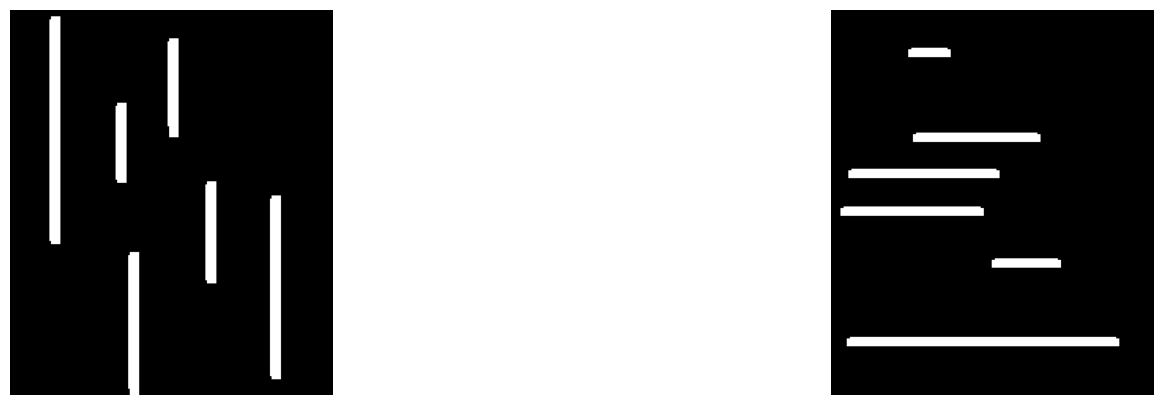

In [95]:
img2 = cv2.imread("art2.png", cv2.IMREAD_GRAYSCALE)

# Elimina os ruídos da diagonal 4, 13
kernelVertical = np.ones((4,13),np.uint8)

# Funciona com 9, 3
kernelHorizontal = np.ones((9,3),np.uint8)

# Erosão para pegar horizontal ou vertical
vertical = cv2.erode(img2, kernelVertical, iterations=1)
horizontal = cv2.erode(img2, kernelHorizontal, iterations=1)

# Recuperando um pouco o tamanho original
diluirVertical = cv2.dilate(vertical, cv2.getStructuringElement(cv2.MORPH_RECT,(4, 4)), iterations=1)
diluirHorizontal = cv2.dilate(horizontal, cv2.getStructuringElement(cv2.MORPH_RECT,(4, 4)), iterations=1)


# Plot das imagens resultantes
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(diluirHorizontal, cmap='gray', vmin=0, vmax=255)
plt.axis('off')


plt.subplot(1, 3, 3)
plt.imshow(diluirVertical, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

""" plt.subplot(1, 3, 2)
plt.imshow(img2, cmap='gray', vmin=0, vmax=255);
plt.axis('off') """

3)

a) Theshold (t=210)

b) Utilizando abertura com elemento circular de 11 pixels para reter as células grandes

c) É possível reter somente os objetos pequenos utilizando a operação abertura?

(np.float64(-0.5), np.float64(449.5), np.float64(449.5), np.float64(-0.5))

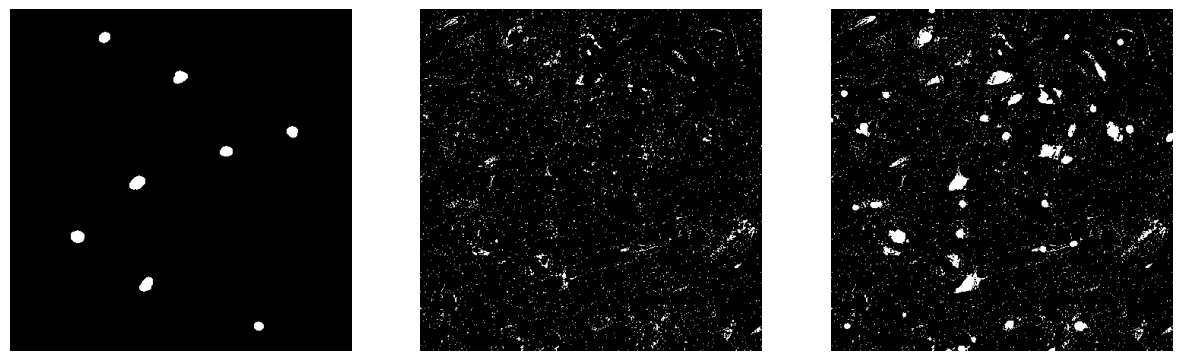

In [132]:
img3 = cv2.imread("cel4.png", cv2.IMREAD_GRAYSCALE)

# a)
_,imgBinarizada = cv2.threshold(img3, 210, 255, cv2.THRESH_BINARY)
imgBinarizada2 = cv2.bitwise_not(imgBinarizada)

# b)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(11, 11))
erosion = cv2.erode(imgBinarizada2, kernel,iterations = 1)
celulasGrande = cv2.dilate(erosion,kernel,iterations = 1)

# c) Não, a operação de abertura não consegue eliminar as células grandes e deixar as pequenas
# Para isso subtraimos a imagem original pela imagem com operação de abertura
# c) Solução
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5, 5))
erosion = cv2.erode(imgBinarizada2, kernel,iterations = 1)
kernelMenor = cv2.dilate(erosion,kernel,iterations = 1)
imgPequenas = cv2.subtract(imgBinarizada2, kernelMenor)


# Plot das imagens resultantes
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(celulasGrande, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(imgPequenas, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(imgBinarizada2, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

4)
Utilizando os conceitos já aprendidos na disciplina, faça um código que calcula a quantidade de objetos da imagem abaixo. Pode-se utilizar funções prontas do opencv (não para realizar a contagem em si, mas para realizar os passos necessários)

Quantidade de feijões encontrados (Contagem na Mão): 89


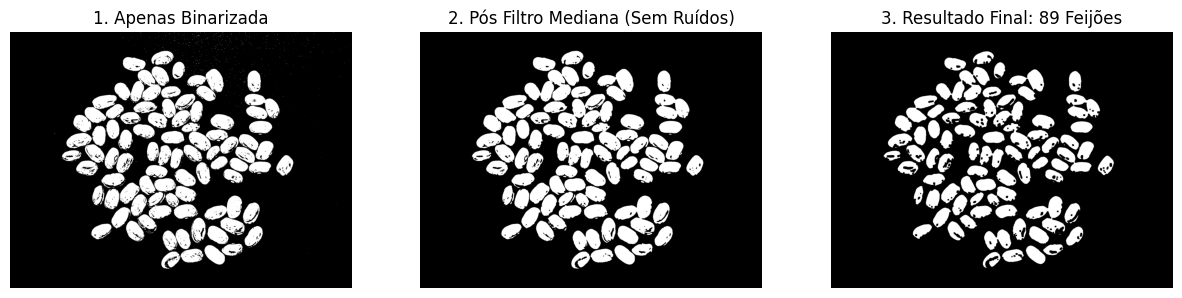

In [ ]:
def encontrarCC(imagem_binaria, vizinhanca=4):
    img = (imagem_binaria > 0).astype(np.int32)
    altura, largura = img.shape
    rotulos = np.zeros((altura, largura), dtype=np.int32)
    proximo_rotulo = 1

    if vizinhanca == 4:
        deslocamentos = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    else: 
        deslocamentos = [(-1, 0), (1, 0), (0, -1), (0, 1),  
                         (-1, -1), (-1, 1), (1, -1), (1, 1)] 

    for y in range(altura):
        for x in range(largura):
            if img[y, x] == 1 and rotulos[y, x] == 0:
                fila = [(y, x)]
                rotulos[y, x] = proximo_rotulo
                
                while len(fila) > 0:
                    atual_y, atual_x = fila.pop(0)
                    for dy, dx in deslocamentos:
                        ny, nx = atual_y + dy, atual_x + dx
                        if 0 <= ny < altura and 0 <= nx < largura:
                            if img[ny, nx] == 1 and rotulos[ny, nx] == 0:
                                rotulos[ny, nx] = proximo_rotulo 
                                fila.append((ny, nx))          
                proximo_rotulo += 1

    return rotulos, (proximo_rotulo - 1)

img4 = cv2.imread("feijao.jpg", cv2.IMREAD_GRAYSCALE)

_, imgBinarizada = cv2.threshold(img4, 100, 255, cv2.THRESH_BINARY)

imgSuave = cv2.medianBlur(imgBinarizada, 15)  # Kernel 15x15 para suavizar bem o interior

kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 1))
kernel_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 15))

imgSeparada = cv2.erode(imgSuave, kernel_h, iterations=1)
imgSeparada = cv2.erode(imgSeparada, kernel_v, iterations=1)

kernel_suave = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
imgFinal = cv2.dilate(imgSeparada, kernel_suave, iterations=1)

matriz_rotulos, total_feijoes = encontrarCC(imgFinal, vizinhanca=8)

# Precisa dar 89 feijões 🙏
print(f"Quantidade de feijões encontrados (Contagem na Mão): {total_feijoes}")

# --- Plot do Passo a Passo ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("1. Apenas Binarizada")
plt.imshow(imgBinarizada, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("2. Pós Filtro Mediana (Sem Ruídos)")
plt.imshow(imgSuave, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title(f"3. Resultado Final: {total_feijoes} Feijões")
plt.imshow(imgFinal, cmap='gray')
plt.axis('off')

plt.show()

5.  Utilize a transformada hit or miss para localizar o logotipo da UFU. Escolha um deles

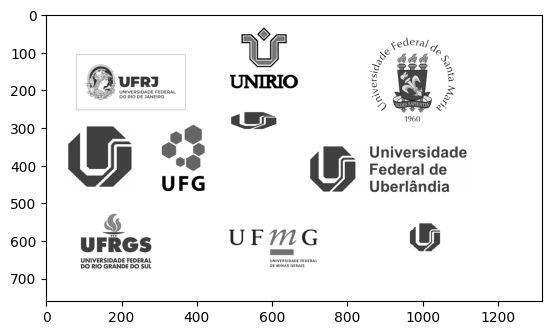

In [4]:
img5 = cv2.imread("logotipos.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(img5, cmap='gray', vmin=0, vmax=255);

6. Utilize operadores morfológicos para extração de fronteiras dos feijões. Mostre o resultado junto com a imagem original